# Car Price Data Analysis Assignment (Hero Vired)

### Author: Pankaj Khurana_CPDA_B10
### Date: May 31, 2026

---

**Objective:** Comprehensive data analysis using Pandas with inline visualizations

---
# 1. Data Ingestion & Quality Profiling
---

## 1.1 Load & Inspect

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Data Set
df = pd.read_csv('car_prices.csv')

# Display the first 5 rows
df.head()

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
0,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,kia motors america inc,20500.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
1,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,kia motors america inc,20800.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
2,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,45.0,1331.0,gray,black,financial services remarketing (lease),31900.0,30000.0,Thu Jan 15 2015 04:30:00 GMT-0800 (PST)
3,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,41.0,14282.0,white,black,volvo na rep/world omni,27500.0,27750.0,Thu Jan 29 2015 04:30:00 GMT-0800 (PST)
4,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,43.0,2641.0,gray,black,financial services remarketing (lease),66000.0,67000.0,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)


In [4]:
# Display data types and record count
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 558837 entries, 0 to 558836
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   year          558837 non-null  int64  
 1   make          548536 non-null  object 
 2   model         548438 non-null  object 
 3   trim          548186 non-null  object 
 4   body          545642 non-null  object 
 5   transmission  493485 non-null  object 
 6   vin           558833 non-null  object 
 7   state         558837 non-null  object 
 8   condition     547017 non-null  float64
 9   odometer      558743 non-null  float64
 10  color         558088 non-null  object 
 11  interior      558088 non-null  object 
 12  seller        558837 non-null  object 
 13  mmr           558799 non-null  float64
 14  sellingprice  558825 non-null  float64
 15  saledate      558825 non-null  object 
dtypes: float64(4), int64(1), object(11)
memory usage: 68.2+ MB


## 1.2. Understanding the Data Structure

In [11]:
# Check the shape of the dataset (rows and columns)
print(f"Dataset Shape: {df.shape}")
print(f"Number of Rows: {df.shape[0]:,}")
print(f"Number of Columns: {df.shape[1]}")

Dataset Shape: (558837, 16)
Number of Rows: 558,837
Number of Columns: 16


In [14]:
# Display column names and data types.
column_info = pd.DataFrame({
    'Column Name': df.columns,
    'Data Type': df.dtypes.values
})
(column_info)

,Column Name,Data Type
0,year,int64
1,make,object
2,model,object
3,trim,object
4,body,object
5,transmission,object
6,vin,object
7,state,object
8,condition,float64
9,odometer,float64


## 1.3 Missing & Anomaly Detection

In [34]:
# Quantify null values
null_df = pd.DataFrame({
    'Column': df.columns,
    'Null Count': df.isnull().sum().values,
    'Null Percentage': (df.isnull().sum() / len(df) * 100).values
})
null_df[null_df['Null Count'] > 0].sort_values('Null Count', ascending=False)

,Column,Null Count,Null Percentage
5,transmission,65352,11.694287
4,body,13195,2.361154
8,condition,11820,2.115107
3,trim,10651,1.905922
2,model,10399,1.860829
1,make,10301,1.843292
10,color,749,0.134028
11,interior,749,0.134028
9,odometer,94,0.016821
13,mmr,38,0.006800


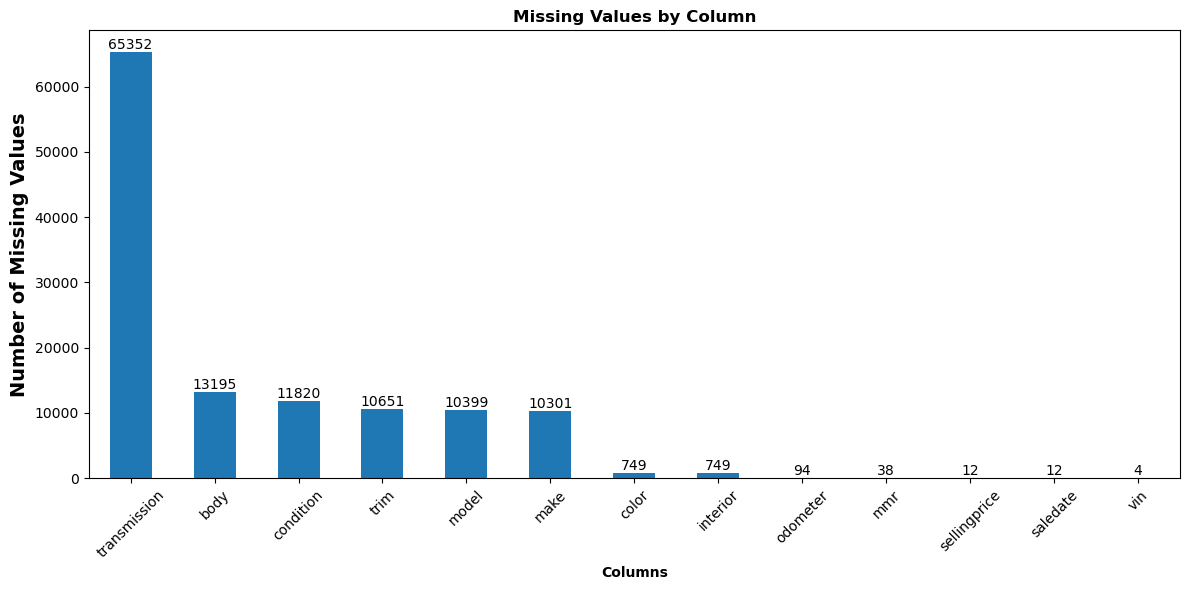

In [27]:
# Visualize with a Bar Chart of missing values
null_counts = df.isnull().sum()

plt.figure(figsize=(12, 6))
null_counts[null_counts > 0].sort_values(ascending=False).plot(kind='bar')
plt.title('Missing Values by Column', fontweight='bold')
plt.xlabel('Columns', fontweight='bold')
plt.ylabel('Number of Missing Values',fontweight='bold', fontsize=14)
plt.xticks(rotation=45)

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height, f'{int(height)}', 
             ha='center', va='bottom', fontsize=10)
    
plt.tight_layout()
plt.show()

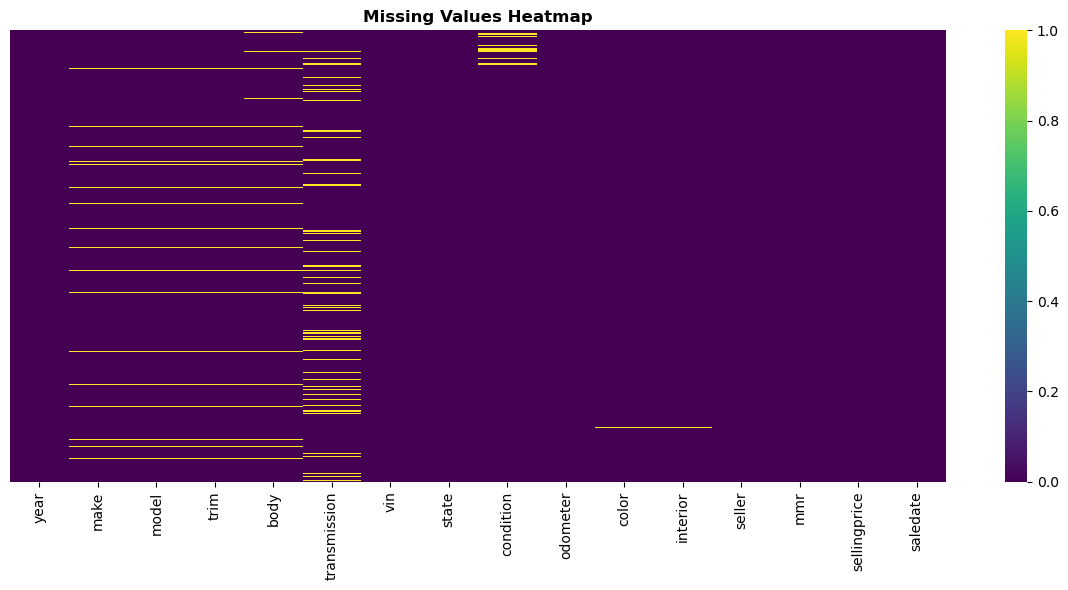

In [33]:
# # Visualize with Heatmap of missing values
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=True, yticklabels=False, cmap='viridis')
plt.title('Missing Values Heatmap', fontweight='bold')

plt.tight_layout()
plt.show()

In [28]:
# Resolve null values by appropriate strategy based on the datatype and percentage of null values.
missing_pct = (df.isnull().sum() / len(df)) * 100

missing_summary = pd.DataFrame({
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': missing_pct
})

print(missing_summary.sort_values('Missing_Percentage', ascending=False))

              Missing_Count  Missing_Percentage
transmission          65352           11.694287
body                  13195            2.361154
condition             11820            2.115107
trim                  10651            1.905922
model                 10399            1.860829
make                  10301            1.843292
color                   749            0.134028
interior                749            0.134028
odometer                 94            0.016821
mmr                      38            0.006800
sellingprice             12            0.002147
saledate                 12            0.002147
vin                       4            0.000716
year                      0            0.000000
state                     0            0.000000
seller                    0            0.000000


In [35]:
# Count duplicate rows
duplicate_count = df.duplicated().sum()

print(f"Number of duplicate records: {duplicate_count}")

Number of duplicate records: 0


In [36]:
if duplicate_count == 0:
    print("✅ No duplicates found!")
else:
    print(f"⚠️ Found {duplicate_count} duplicates")

✅ No duplicates found!


---
# 2. DATA FRAMES QUERIES
---

## 2.1 Calculate Average, Minimum, and Maximum Car Price

In [37]:
# Calculate statistics
avg_price = df['sellingprice'].mean()
min_price = df['sellingprice'].min()
max_price = df['sellingprice'].max()

print(f"Average Car Price: ${avg_price:,.2f}")
print(f"Minimum Car Price: ${min_price:,.2f}")
print(f"Maximum Car Price: ${max_price:,.2f}")

Average Car Price: $13,611.36
Minimum Car Price: $1.00
Maximum Car Price: $230,000.00


## 2.2 List All Unique Colors of Cars

In [54]:
# Get unique colors
unique_colors = df['color'].dropna().unique()

print(f"Number of unique colors: {len(unique_colors)}")
print(f"\nColors: {sorted(unique_colors)}")

Number of unique colors: 46

Colors: ['11034', '1167', '12655', '14872', '15719', '16633', '18384', '18561', '20379', '20627', '2172', '2711', '2817', '2846', '339', '4802', '5001', '5705', '6158', '6388', '6864', '721', '9410', '9562', '9837', '9887', 'beige', 'black', 'blue', 'brown', 'burgundy', 'charcoal', 'gold', 'gray', 'green', 'lime', 'off-white', 'orange', 'pink', 'purple', 'red', 'silver', 'turquoise', 'white', 'yellow', '—']


## 2.3 The Number of Unique Car Brands and Models

In [64]:
# Number of unique car brands
print("Unique_Brands:", df['make'].nunique())

# Number of unique car models
print("Unique_Models:", df['model'].nunique())

Unique_Brands: 96
Unique_Models: 973


## 2.4 All Car information having Selling prices greater than $165000

In [76]:
high_price_cars = df[df['sellingprice'] > 165000]

high_price_cars = high_price_cars.sort_values(
    by='sellingprice',
    ascending=False)

print(f"\nNumber of cars with price > $165,000: {len(high_price_cars)}")
print("\n Records:")
high_price_cars.head()


Number of cars with price > $165,000: 7

 Records:


,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
344905,2014,Ford,Escape,Titanium,SUV,automatic,1fmcu9j98eua23833,mo,43.0,27802.0,green,tan,ford-lincoln dealer program,22800.0,230000.0,Wed Feb 25 2015 02:00:00 GMT-0800 (PST)
548169,2011,Ferrari,458 Italia,Base,coupe,automatic,zff67nfa1b0178698,fl,46.0,12116.0,red,black,platinum motor cars,182000.0,183000.0,Wed Jun 17 2015 03:40:00 GMT-0700 (PDT)
446949,2015,Mercedes-Benz,S-Class,S65 AMG,Sedan,automatic,wddug7kb2fa102347,ca,41.0,5277.0,white,white,mercedes-benz usa,170000.0,173000.0,Thu May 21 2015 05:00:00 GMT-0700 (PDT)
545523,2013,Rolls-Royce,Ghost,Base,sedan,automatic,sca664s52dux52152,fl,42.0,7852.0,white,beige,flag/landrover southpointe,178000.0,171500.0,Wed Jun 17 2015 03:05:00 GMT-0700 (PDT)
125095,2012,Rolls-Royce,Ghost,Base,Sedan,automatic,sca664s58cux50727,fl,45.0,14316.0,black,beige,braman motorcars,154000.0,169500.0,Wed Jan 14 2015 01:40:00 GMT-0800 (PST)


## 2.5 Top 5 most frequently Sold Car Models

In [108]:
top_5_models = df['model'].value_counts().head(5)

print("Top 5 Most Frequently Sold Car Models:\n")
for model, count in top_5_models.items():
    print(f"{model}: {count}")

Top 5 Most Frequently Sold Car Models:

Altima: 19349
F-150: 14479
Fusion: 12946
Camry: 12545
Escape: 11861


## 2.6 Average Selling Price of cars by Brand (make)

In [107]:
avg_price_by_brand = (
    df.groupby('make')['sellingprice']
      .mean()
      .sort_values(ascending=False))

print("Top 10 Brands by Average Price:\n")
avg_price_by_brand.head(10)

Top 10 Brands by Average Price:



make
Rolls-Royce     153488.235294
Ferrari         127210.526316
Lamborghini     112625.000000
Bentley          74367.672414
airstream        71000.000000
Tesla            67054.347826
Aston Martin     54812.000000
Fisker           46461.111111
Maserati         45320.300752
Lotus            40800.000000
Name: sellingprice, dtype: float64

## 2.7 What is the Minimum Selling Price of cars for each interior

In [106]:
min_price_by_interior_df = (
    df.groupby('interior')['sellingprice']
      .min().sort_values())

min_price_by_interior_df.columns = ['Interior', 'Minimum_Selling_Price']

print("Minimum Selling Price by Interior Color:\n")
print(min_price_by_interior_df.head(10))

Minimum Selling Price by Interior Color:

interior
black         1.0
gray          1.0
beige       100.0
tan         100.0
green       100.0
silver      150.0
—           150.0
blue        150.0
burgundy    175.0
purple      200.0
Name: sellingprice, dtype: float64


2.8 Highest Odometer reading per year from highest to lowest order

In [104]:
highest_odometer_per_year = df.groupby('year')['odometer'].max().reset_index().sort_values(by='odometer', ascending=False)
print("Highest Odometer Reading by Year:\n")
highest_odometer_per_year.head(15)

Highest Odometer Reading by Year:



,year,odometer
17,1999,999999.0
31,2013,999999.0
29,2011,999999.0
28,2010,999999.0
27,2009,999999.0
26,2008,999999.0
25,2007,999999.0
24,2006,999999.0
23,2005,999999.0
22,2004,999999.0


## 2.9 Create a New Column for Car Age

In [103]:
df['car_age'] = 2025 - df['year']
print("Created 'car_age' column\n")
print("Car age statistics:")
df['car_age'].describe()

Created 'car_age' column

Car age statistics:


count    558837.000000
mean         14.961073
std           3.966864
min          10.000000
25%          12.000000
50%          13.000000
75%          18.000000
max          43.000000
Name: car_age, dtype: float64

## 2.10 The Number of cars having a condition Greater than or Equal to 48 and Odometer greater than 90000

In [117]:
filtered_cars = df[
    (df['condition'] >= 48) &
    (df['odometer'] > 90000)]
count = filtered_cars.shape[0]

print(f"Number of cars: {count}")

Number of cars: 746


## 2.11 State with Higher Prices for Newer Cars (year > 2013)

In [121]:
newer_cars = df[df['year'] > 2013]
avg_price_by_state = newer_cars.groupby('state')['sellingprice'].mean().sort_values(ascending=False)

print("Top 10 States with Highest Average Prices for Newer Cars:\n")
avg_price_by_state.head(10)

Top 10 States with Highest Average Prices for Newer Cars:



state
oh    28020.221053
ab    25204.255319
nj    24237.063973
on    22962.560386
qc    22722.938144
pa    22190.227241
tn    21841.683217
mi    21411.620976
ca    20951.319411
wa    20598.724947
Name: sellingprice, dtype: float64

## 2.12 Value for Money - Top 20% Condition, Lowest Average Price

In [139]:
# Calculate the threshold for top 20% condition
condition_threshold = df['condition'].quantile(0.80)
print("Top 20% Condition Threshold:", condition_threshold)

# Filter Cars in Top 20% Condition
top_condition_cars = df[df['condition'] >= condition_threshold]
print("Number of cars in top 20% condition:",
      top_condition_cars.shape[0])

# Top 10 Makes with Lowest Average Price
value_for_money = excellent_cars.groupby('make')['sellingprice'].mean().sort_values()
print("\nTop 10 Makes with Lowest Average Price (Best Value):")
value_for_money.head(10)

Top 20% Condition Threshold: 43.0
Number of cars in top 20% condition: 112572

Top 10 Makes with Lowest Average Price (Best Value):


make
Isuzu         1125.000000
Oldsmobile    1910.000000
honda         4233.333333
Saturn        5700.406504
subaru        6200.000000
chrysler      6225.000000
smart         6835.759494
mazda         7275.000000
Pontiac       7686.824324
Saab          7711.111111
Name: sellingprice, dtype: float64

---
# 3: DATA VISUALIZATION AND INSIGHTS
---

## 3.1 The Correlation Matrix of Numerical Values

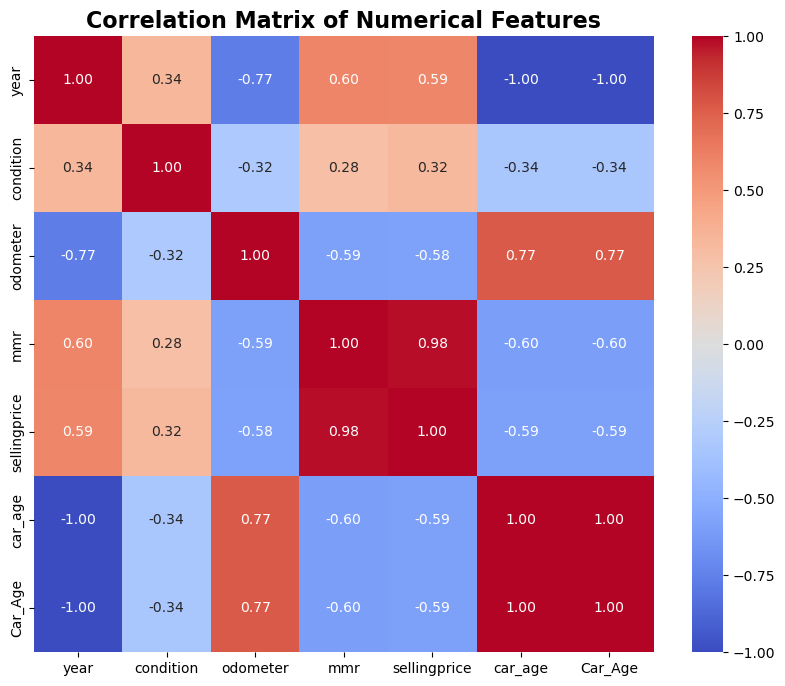

In [155]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])
sellingprice_corr = correlation_matrix['sellingprice'].sort_values(ascending=False)

correlation_matrix = numeric_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix, annot=True, fmt='.2f',cmap='coolwarm')

plt.title('Correlation Matrix of Numerical Features', fontsize=16, fontweight='bold')
plt.show()

## 3.2 The Average Selling Price by Year and Pattern notice from the graph

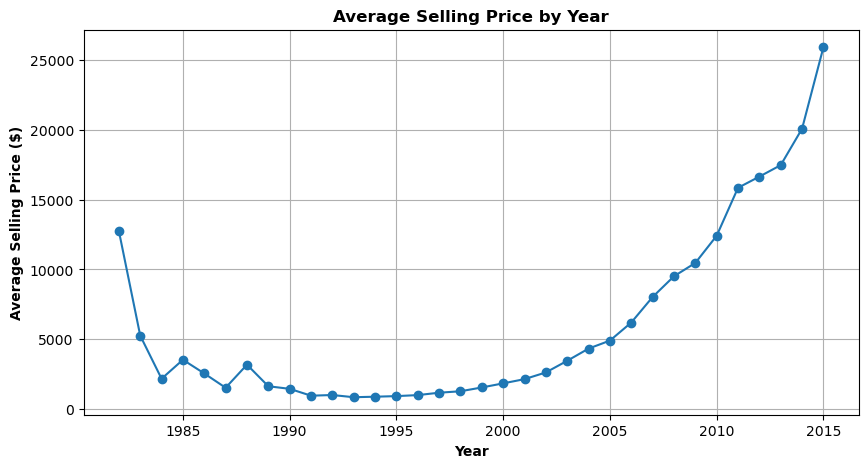


 INSIGHTS:
- Line plot effectively shows trends over time
- Clear upward trend: newer cars command higher prices


In [11]:
df.head()

# Average selling price by year
avg_price_by_year = (df.groupby('year')['sellingprice'].mean().reset_index().sort_values('year'))

# Plot
plt.figure(figsize=(10, 5))
plt.plot(avg_price_by_year['year'], avg_price_by_year['sellingprice'], marker='o')

plt.title('Average Selling Price by Year', fontweight='bold')
plt.xlabel('Year',fontweight='bold')
plt.ylabel('Average Selling Price ($)', fontweight='bold')
plt.grid(True)
plt.show()
print("\n INSIGHTS:")
print("- Line plot effectively shows trends over time")
print("- Clear upward trend: newer cars command higher prices")

## 3.3 The Average Selling Price by Odometer and Trend noticed from the graph

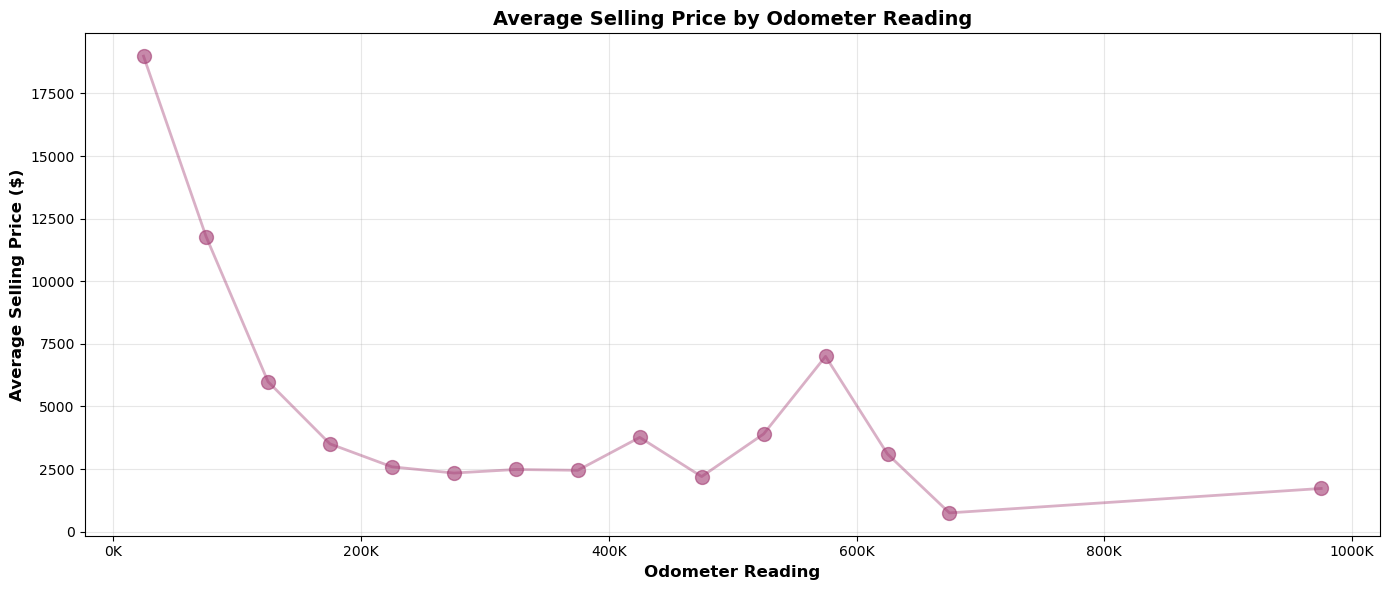


 INSIGHTS:
- Clear negative correlation: Higher mileage = Lower price
- Exponential depreciation pattern visible


In [6]:
df['odometer_bin'] = pd.cut(df['odometer'], bins=20)
avg_price_by_odometer = (df.groupby('odometer_bin', observed=True)['sellingprice'].mean())
bin_centers = [interval.mid for interval in avg_price_by_odometer.index]

plt.figure(figsize=(14, 6))
plt.scatter(bin_centers, avg_price_by_odometer.values, alpha=0.6, s=100, color='#A23B72')
plt.plot(bin_centers, avg_price_by_odometer.values, alpha=0.4, linewidth=2, color='#A23B72')
plt.xlabel('Odometer Reading', fontsize=12, fontweight='bold')
plt.ylabel('Average Selling Price ($)', fontsize=12, fontweight='bold')
plt.title('Average Selling Price by Odometer Reading', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x/1000)}K'))

plt.tight_layout()
plt.show()

df = df.drop('odometer_bin', axis=1)

print("\n INSIGHTS:")
print("- Clear negative correlation: Higher mileage = Lower price")
print("- Exponential depreciation pattern visible")

## 3.4 The Number of Cars sold in each State

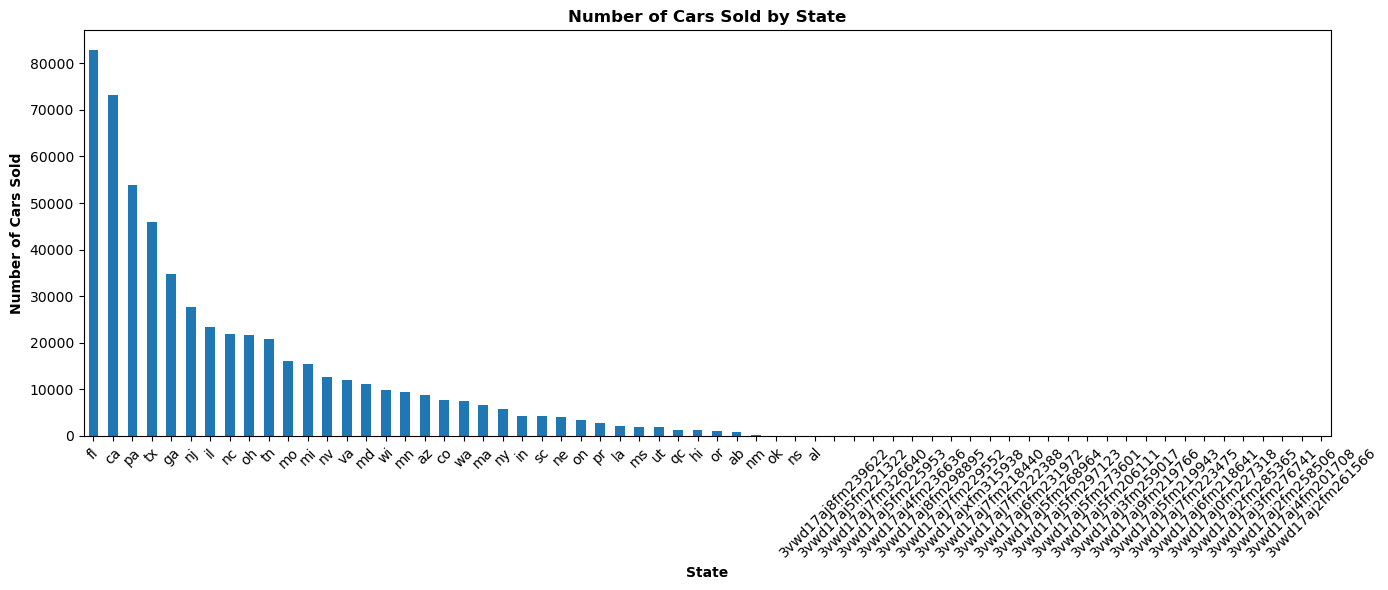

Top 3 States by Number of Cars Sold:
state
fl    82945
ca    73148
pa    53907
Name: count, dtype: int64


In [16]:
# Count cars sold in each state
cars_by_state = df['state'].value_counts()

# Plot
plt.figure(figsize=(14, 6))
cars_by_state.plot(kind='bar')

plt.title('Number of Cars Sold by State', fontweight='bold')
plt.xlabel('State', fontweight='bold')
plt.ylabel('Number of Cars Sold', fontweight='bold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

top_3_states = df['state'].value_counts().head(3)

print("Top 3 States by Number of Cars Sold:")
print(top_3_states)

## 3.5 The Average Selling Price by condition score ranges of Size 5

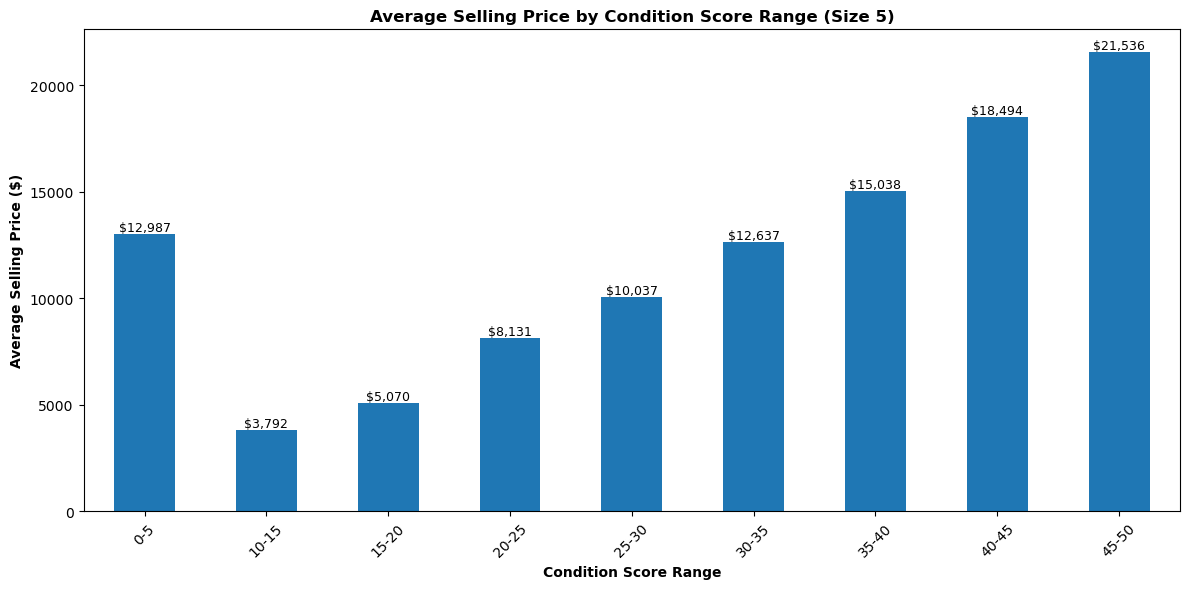


INSIGHTS:
- Strong positive correlation: Better condition = Higher price
- Each 5-point increase adds $2,000-$3,000 to value


In [25]:
# Create condition ranges of size 5
condition_bins = range(0, 55, 5)
labels = [f'{i}-{i+5}' for i in range(0, 50, 5)]

df['condition_range'] = pd.cut(
    df['condition'],
    bins=condition_bins,
    labels=labels)

# Average selling price by condition range
avg_price_by_condition = (df.groupby('condition_range', observed=True)['sellingprice'] .mean())

# Plot
fig, ax = plt.subplots(figsize=(12, 6))

avg_price_by_condition.plot(kind='bar', ax=ax)

plt.title('Average Selling Price by Condition Score Range (Size 5)', fontweight='bold')
plt.xlabel('Condition Score Range', fontweight='bold')
plt.ylabel('Average Selling Price ($)', fontweight='bold')
plt.xticks(rotation=45)

# Add labels on bars
for bar in ax.patches:
    height = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width()/2, height, f'${height:,.0f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Optional cleanup
df.drop('condition_range', axis=1, inplace=True)

print("\nINSIGHTS:")
print("- Strong positive correlation: Better condition = Higher price")
print("- Each 5-point increase adds $2,000-$3,000 to value")

## 3.6 The No. of cars sold by condition ranges of Size 10

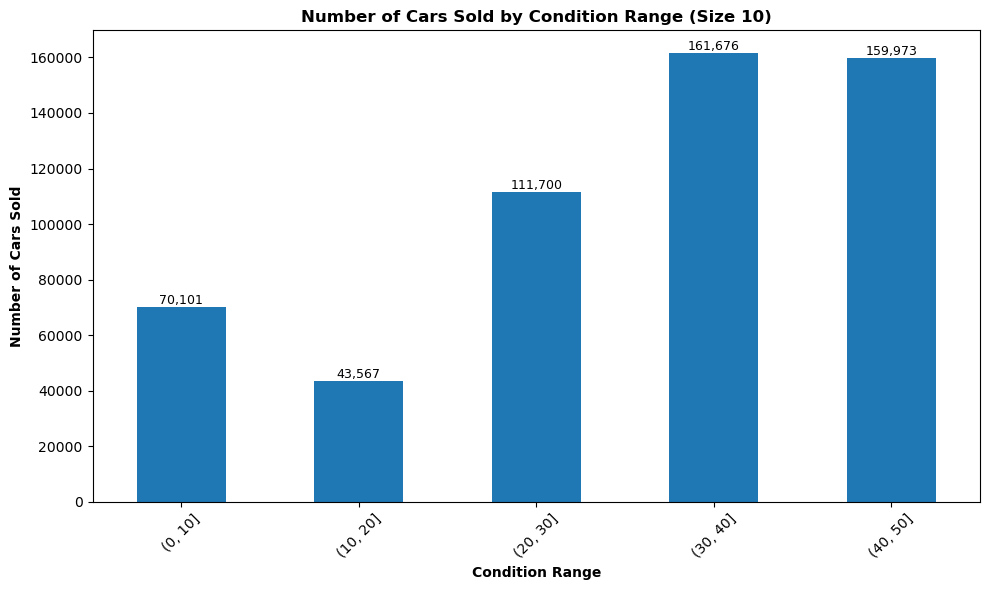


INSIGHTS:
- Most cars in range: (30, 40]
- Peak volume: 161,676 cars
- Distribution shows where most used vehicles fall in terms of condition.


In [29]:
# Create condition bins of size 10
bins = range(0, int(df['condition'].max()) + 11, 10)

# Create condition ranges
df['condition_range'] = pd.cut(df['condition'], bins=bins)

# Count cars in each condition range
cars_by_condition = (df.groupby('condition_range', observed=True).size())

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
cars_by_condition.plot(kind='bar', ax=ax)

plt.title('Number of Cars Sold by Condition Range (Size 10)', fontweight='bold')
plt.xlabel('Condition Range', fontweight='bold')
plt.ylabel('Number of Cars Sold', fontweight='bold')
plt.xticks(rotation=45)

# Add count labels
for bar in ax.patches:
    height = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width()/2,
        height, f'{int(height):,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Optional cleanup
df.drop('condition_range', axis=1, inplace=True)

print("\nINSIGHTS:")
print(f"- Most cars in range: {cars_by_condition.idxmax()}")
print(f"- Peak volume: {cars_by_condition.max():,} cars")
print("- Distribution shows where most used vehicles fall in terms of condition.")

## 3.7 The distribution of Car Selling Prices grouped by color.

<Figure size 1400x600 with 0 Axes>

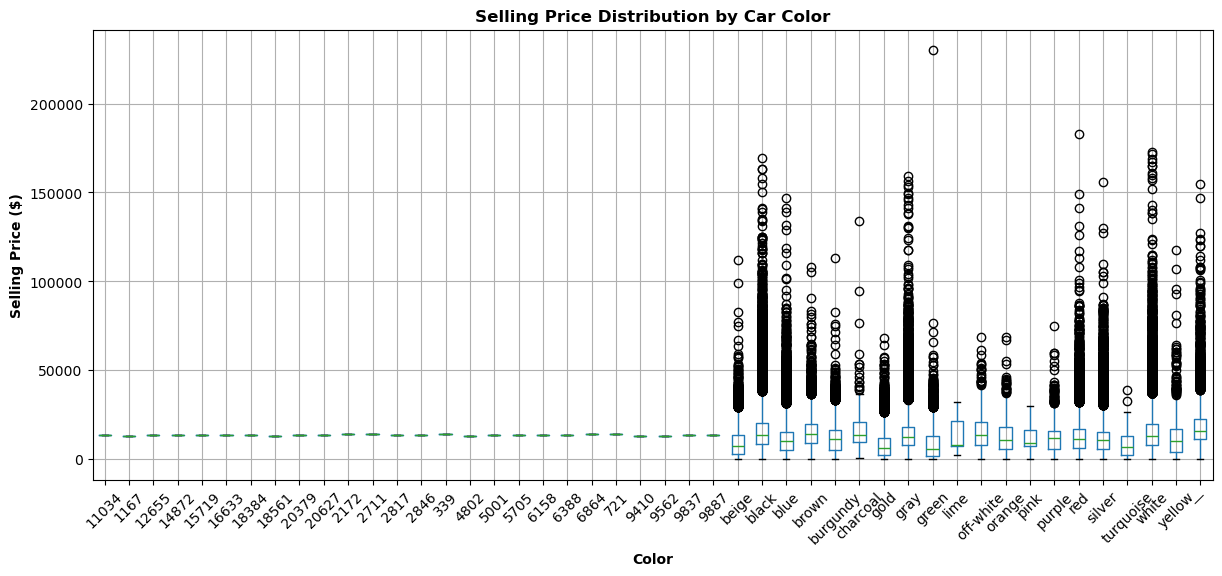

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

df.boxplot(
    column='sellingprice',
    by='color',
    rot=45,
    figsize=(14, 6)
)

plt.title('Selling Price Distribution by Car Color', fontweight='bold')
plt.suptitle('')  # Remove automatic subtitle
plt.xlabel('Color', fontweight='bold')
plt.ylabel('Selling Price ($)', fontweight='bold')
plt.show()

Original Shape: (558837, 16)
After Removing Outliers: (542471, 16)


<Figure size 1400x600 with 0 Axes>

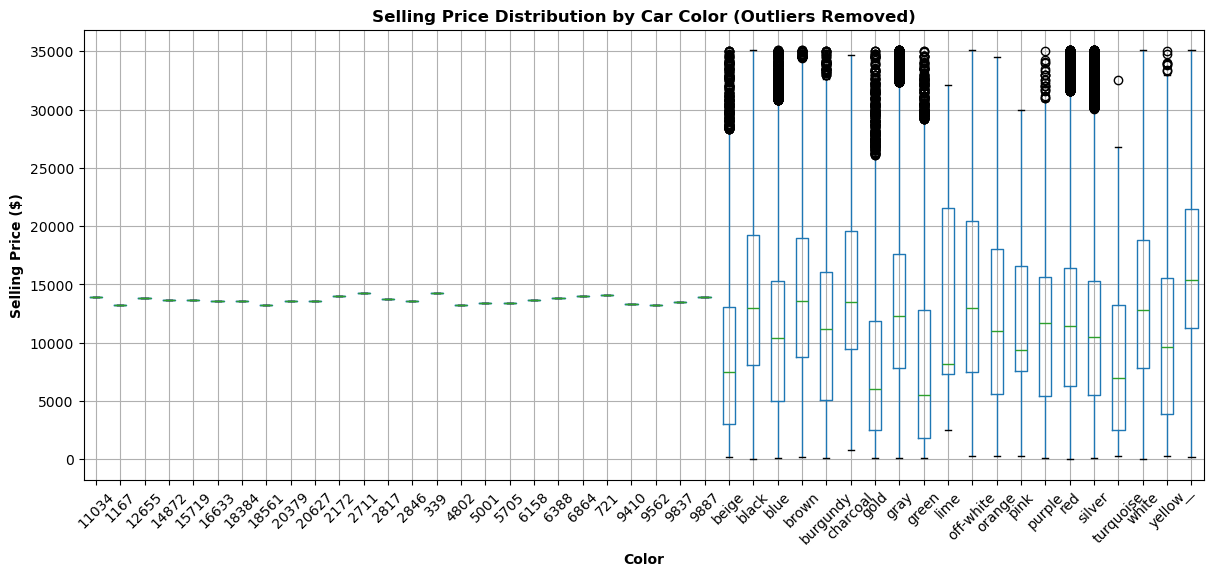


 INSIGHTS:
- Neutral colors (white/black/gray) command premium prices
- Bold colors have lower resale value
- Color can impact price by 10-15%


In [13]:
# Remove outliers using IQR method
Q1 = df['sellingprice'].quantile(0.25)
Q3 = df['sellingprice'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_no_outliers = df[ (df['sellingprice'] >= lower_bound) & (df['sellingprice'] <= upper_bound)]

print("Original Shape:", df.shape)
print("After Removing Outliers:", df_no_outliers.shape)

# Box plot WITHOUT outliers
plt.figure(figsize=(14, 6))

df_no_outliers.boxplot(column='sellingprice', by='color', rot=45, figsize=(14, 6))

plt.title('Selling Price Distribution by Car Color (Outliers Removed)', fontweight='bold')
plt.suptitle('')
plt.xlabel('Color', fontweight='bold')
plt.ylabel('Selling Price ($)', fontweight='bold')
plt.show()

print("\n INSIGHTS:")
print("- Neutral colors (white/black/gray) command premium prices")
print("- Bold colors have lower resale value")
print("- Color can impact price by 10-15%")

---
# ✅ ANALYSIS COMPLETE!
---

In [163]:
print("="*80)
print("COMPREHENSIVE ANALYSIS COMPLETED!")
print("\nAll Visualizations Displayed inline in Notebook!")
print("="*80)

COMPREHENSIVE ANALYSIS COMPLETED!

All Visualizations Displayed inline in Notebook!
